Gruppe 1:

Fabian Ziegler (91235, zifa1013)

Martina Schmidt (97522, scma1335)

Enyen Xia (96541, xien1011)

Huong Giang Pham (98350, phhu1011)

# 1. Bibliotheken importieren & Data Loading

In [1]:
import os
import pandas as pd                 
import numpy as np                  
import matplotlib.pyplot as plt     
import seaborn as sns
import missingno as msno
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import chi2_contingency

In [2]:
os.getcwd()

'/Users/xey/Desktop/DABI_Projekt'

In [3]:
df_new_clickstreams=pd.read_csv(r'data/clickstreams.csv.zip')
df_new_geo_info=pd.read_csv(r'data/new_geo_info_.csv')
df_new_statistics=pd.read_csv(r'data/new_statistics_.csv')
df_new_user=pd.read_csv(r'data/new_user_.csv')

# 2. Explorative Datenanalyse & Datenbereinigung & Feature Engineering

## User-Daten

In [5]:
df_new_user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213451 entries, 0 to 213450
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   user_id                  213451 non-null  object 
 1   account_created_date     213451 non-null  object 
 2   first_active_timestamp   213451 non-null  int64  
 3   first_booking_date       88908 non-null   object 
 4   user_gender              213451 non-null  object 
 5   user_age                 125461 non-null  float64
 6   signup_platform          213451 non-null  object 
 7   signup_process           213451 non-null  int64  
 8   user_language            213451 non-null  object 
 9   marketing_channel        213451 non-null  object 
 10  marketing_provider       213451 non-null  object 
 11  first_tracked_affiliate  207386 non-null  object 
 12  signup_application       213451 non-null  object 
 13  first_device             213451 non-null  object 
 14  firs

In [383]:
df_new_user.describe()
# user_age = [1; 2014] -> Bereinigung von Alterwerte nötig

,first_active_timestamp,user_age,signup_process
count,2.134510e+05,125461.000000,213451.000000
mean,2.013085e+13,49.668335,3.267387
std,9.253717e+09,155.666612,7.637707
min,2.009032e+13,1.000000,0.000000
25%,2.012123e+13,28.000000,0.000000
50%,2.013091e+13,34.000000,0.000000
75%,2.014031e+13,43.000000,0.000000
max,2.014063e+13,2014.000000,25.000000


<Axes: >

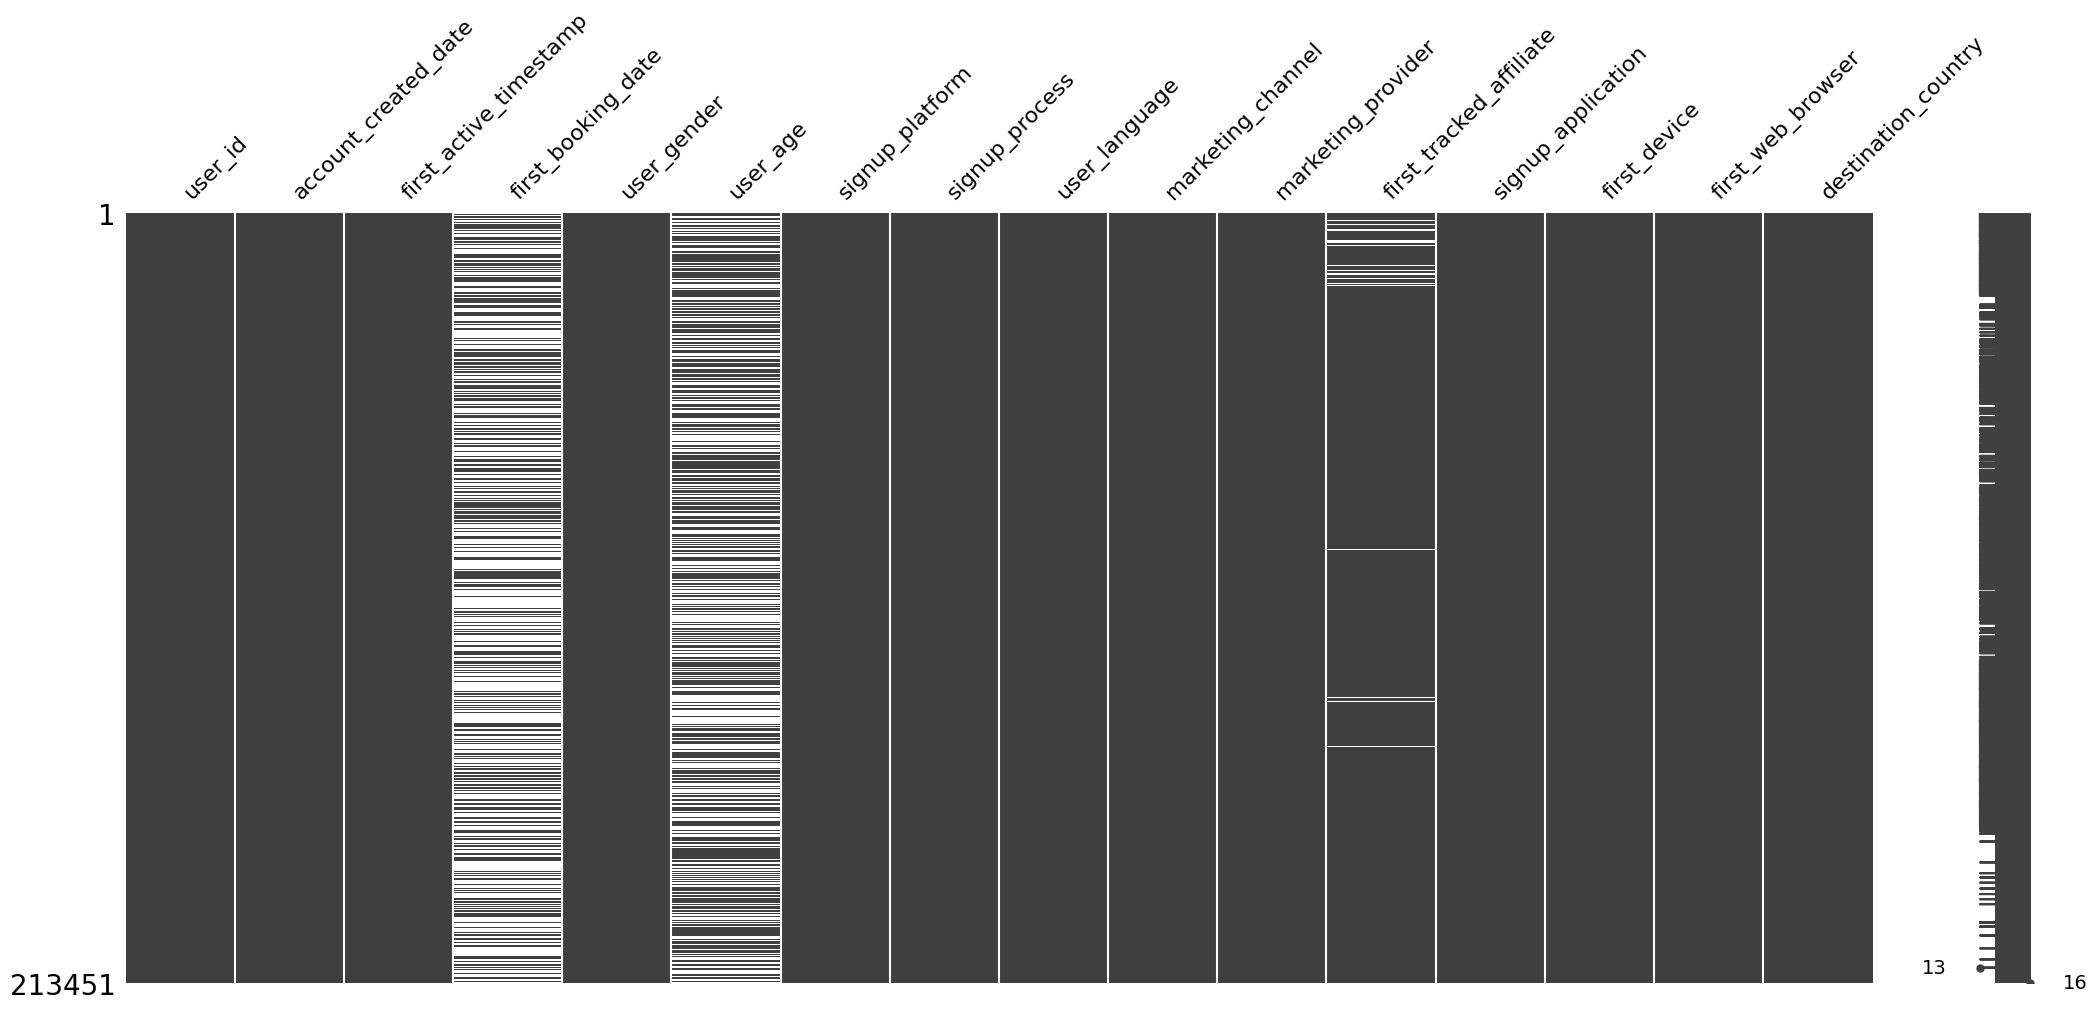

In [6]:
msno.matrix(df_new_user)

Vermutung: User ohne Altersangaben haben wahrscheinlich noch nicht gebucht.

In [7]:
# Spalte 'hat_gebucht': Hat der Nutzer gebucht oder nicht?
df_new_user['hat_gebucht'] = df_new_user['destination_country'] != 'NDF'

#  Prozentsatz der fehlenden Altersangaben pro Gruppe
missing_stats = df_new_user.groupby('hat_gebucht')['user_age'].apply(lambda x: x.isnull().mean()) # x.isnull(): Prüft für jeden Eintrag, ob er leer ist (True) oder nicht (False). MEAN: Da True als 1 und False als 0 zählt, ergibt der Durchschnitt genau den Anteil (Prozentsatz) der fehlenden Werte.

print("Anteil fehlender Altersangaben:")
print(f"Bei Nutzern OHNE Buchung (NDF): {missing_stats[False]:.1%}")
print(f"Bei Nutzern MIT Buchung:        {missing_stats[True]:.1%}")

Anteil fehlender Altersangaben:
Bei Nutzern OHNE Buchung (NDF): 54.3%
Bei Nutzern MIT Buchung:        22.9%


In [8]:
df_new_user['destination_country'].unique()

array(['NDF', 'US', 'other', 'FR', 'CA', 'GB', 'ES', 'IT', 'PT', 'NL',
       'DE', 'AU'], dtype=object)

In [9]:
target_countries = ['US', 'GB', 'CA', 'FR', 'ES', 'IT', 'NL', 'NDF', 'other'] # DE, PT, AU entfernen, da zu wenig Daten.

In [10]:
# only select ages above 16 and under 120 as they are deemed as actual customers 
df_user = df_new_user[(df_new_user['user_age'] >= 16) & (df_new_user['user_age'] <= 120)]

# only select destination country from the list target_countries
df_user = df_user[df_user['destination_country'].isin(target_countries)]

# normalise gender naming 
df_user['user_gender'] = (
    df_user['user_gender']
        .str.strip()      
        .str.upper()      
        .replace({'-UNKNOWN-': 'UNKNOWN'})  
)

# binning user_age column in df_user into age groups: 16-24, 25-34, 35-44, 45-54, 55-64, 65+
bins=[16,24,34,44,54,64,100]
labels=['16-24','25-34','35-44','45-54','55-64','65+']
df_user['age_group']=pd.cut(df_user['user_age'], bins=bins, labels=labels)

# split and normalise date, seperate dayofweek, hour, day into seperate columns 
df_user['first_active_timestamp_normalised']=pd.to_datetime(df_user['first_active_timestamp'].astype(str), format='%Y%m%d%H%M%S')
df_user['first_active_timestamp_dayofweek']=df_user['first_active_timestamp_normalised'].dt.dayofweek
df_user['first_active_timestamp_hour']=df_user['first_active_timestamp_normalised'].dt.hour

## Statistics-Daten

In [389]:
# only select country from the list target_countries
df_statistics = df_new_statistics[df_new_statistics['country'].isin(target_countries)]

## Geo-Info-Daten

In [390]:
# only select country from the list target_countries
df_geo = df_new_geo_info[df_new_geo_info['country'].isin(target_countries)]

# 3. Konkrete Fragen 

## Color Palette

In [23]:
color_male_female={"MALE": "#4C72B0",
        "FEMALE": "#e377c2"}
color_heatmap= 'Blues'
color_age_group={
    '16-24':'CadetBlue',
    '25-34':'OrangeRed',
    '35-44': 'Gold',
    '45-54': 'MediumPurple',
    '55-64':'DarkSlateGray',
    '65+':'Teal'}

color_destination_country= {
    'US': '#002147', 
    'FR': '#4169E1', 
    'CA': '#D80621', 
    'GB': '#FF5A5F', 
    'ES': '#FFC400', 
    'IT':'#008C45', 
    'PT':'#2E4600',
    'NL':'#FF8C00', 
    'DE':'#333333', 
    'AU':'#FFE200'
}

## Frage 1: Welche Zusammenhänge gibt es zwischen der Sprache des Users und der Sprache des besuchten Landes?

Wohin geht eine {deutschsprachige} Person?

In [392]:
df_filtered = df_user[~df_user['destination_country'].isin(['NDF', 'other'])].copy()

# Häufigkeit jeder Sprache ermitteln 
lang_counts = df_filtered['user_language'].value_counts()

# Sprachen mit weniger als 50 Reisenden identifizieren
# Diese werden in der Kategorie "andere Sprachen" gruppiert
small_langs = lang_counts[lang_counts < 50].index

# Neue Spalte erstellen: Wenn Sprache selten, dann "andere Sprachen"
df_filtered['user_language_grouped'] = df_filtered['user_language'].apply(
    lambda x: 'andere Sprachen' if x in small_langs else x
)

# Kontingenztafel erstellen
# margins=True fügt die Randhäufigkeiten (Summen) hinzu
crosstab_final = pd.crosstab(
    df_filtered['user_language_grouped'], 
    df_filtered['destination_country'], 
    margins=True,
    normalize='index',
    margins_name='Gesamt'
) *100

# Sortieren nach Gesamtanzahl (absteigend)
# crosstab_final = crosstab_final.sort_values(by='Gesamt', ascending=False)

crosstab_rounded = crosstab_final.round(2)

# Formatierung für die Anzeige (mit Komma und %)
# Dies wandelt die Zahlen in Text um, um die Darstellung zu erzwingen
crosstab_formatted = crosstab_rounded.applymap(lambda x: f"{x:.2f}".replace('.', ','))

# Anzeige
crosstab_formatted

/var/folders/fc/6rgw4jv16sqf7df05yt0flq80000gn/T/ipykernel_16946/894795319.py:32: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



destination_country,CA,ES,FR,GB,IT,NL,US
user_language_grouped,,,,,,,
andere Sprachen,"0,00","6,25","3,75","1,25","2,50","3,75","82,50"
de,"0,61","4,24","4,85","1,82","3,03","1,21","84,24"
en,"1,84","2,84","6,22","3,00","3,41","1,01","81,67"
es,"0,00","8,60","5,91","2,69","3,23","0,54","79,03"
fr,"1,73","3,46","17,30","3,11","3,11","1,04","70,24"
it,"1,27","5,06","3,80","3,80","18,99","1,27","65,82"
ja,"1,89","1,89","5,66","3,77","1,89","0,00","84,91"
ko,"0,79","1,57","5,51","1,57","3,94","0,79","85,83"
ru,"1,32","7,89","5,26","1,32","6,58","0,00","77,63"


In [393]:
df_filtered2 = df_user[~df_user['destination_country'].isin(['NDF', 'other'])].copy()

# Häufigkeit jeder Sprache ermitteln 
lang_counts = df_filtered['user_language'].value_counts()

# Alle Sprachen von Nutzern wählen
# Diese werden in der Kategorie "andere Sprachen" gruppiert
small_langs = lang_counts[lang_counts < 0].index

# Neue Spalte erstellen: Wenn Sprache selten, dann "andere Sprachen"
df_filtered2['user_language_grouped'] = df_filtered2['user_language'].apply(
    lambda x: 'andere Sprachen' if x in small_langs else x
)

crosstab_final_abs = pd.crosstab(
    df_filtered2['user_language_grouped'], 
    df_filtered2['destination_country'], 
    margins=True,
    margins_name='Gesamt'
) 
crosstab_final_abs

destination_country,CA,ES,FR,GB,IT,NL,US,Gesamt
user_language_grouped,,,,,,,,
ca,0,0,0,0,0,0,2,2
cs,0,1,0,0,0,0,3,4
da,0,2,0,0,1,0,12,15
de,1,7,8,3,5,2,139,165
el,0,2,1,0,0,0,2,5
en,1060,1637,3591,1733,1969,583,47122,57695
es,0,16,11,5,6,1,147,186
fi,0,0,1,0,0,0,4,5
fr,5,10,50,9,9,3,203,289


In [394]:
# Mit USA
heatmap_data = crosstab_final

# Sortierung nach der Größe der Sprachgruppen für eine bessere Übersicht
lang_order = df_filtered['user_language_grouped'].value_counts().index
heatmap_data = heatmap_data.reindex(lang_order)

fig_frage1_2 = px.imshow(
    heatmap_data,
    labels=dict(x="Zielland", y="Sprachgruppe", color="Anteil (%)"),
    x=heatmap_data.columns,
    y=heatmap_data.index,
    text_auto='.2f', # Zahlen direkt in der Heatmap anzeigen
    color_continuous_scale='YlGnBu',
    title=' Wohin reisen die Sprachgruppen?'
)
fig_frage1_2.update_layout(height=700, width=900, template='plotly_white')

# Plots anzeigen
fig_frage1_2.show()


In [395]:
country_langs = {
    'US': ['en'],
    'GB': ['en'],
    'CA': ['en'],
    'AU': ['en'],
    'DE': ['de'],
    'FR': ['fr'],
    'ES': ['es'],
    'IT': ['it'],
    'PT': ['pt'],
    'NL': ['nl']
}


**Ohne USA**

In [396]:
heatmap_data = crosstab_final.iloc[:-1, :-1]

# Sortierung nach der Größe der Sprachgruppen für eine bessere Übersicht
lang_order = df_filtered['user_language_grouped'].value_counts().index
heatmap_data = heatmap_data.reindex(lang_order)

fig_frage1 = px.imshow(
    heatmap_data,
    labels=dict(x="Zielland", y="Sprachgruppe", color="Anteil (%)"),
    x=heatmap_data.columns,
    y=heatmap_data.index,
    color_continuous_scale='YlGnBu',
    title='Wohin reisen die Sprachgruppen - Ohne USA'
)

#  Annotationen für die farbige Text-Markierung hinzufügen
annotations = []
for i, lang in enumerate(heatmap_data.index):
    for j, country in enumerate(heatmap_data.columns):
        val = heatmap_data.iloc[i, j]
        
        # Prüfung: Ist die Nutzersprache eine Amtssprache des Ziellandes?
        is_match = lang in country_langs.get(country, [])
        
        # Farbe bestimmen: Rot bei Match, sonst Kontrastfarbe zum Hintergrund
        text_color = "red" if is_match else ("white" if val > 40 else "black")
        font_weight = "Arial Black" if is_match else "Arial"
        font_size = 12 if is_match else 10
        
        annotations.append(
            go.layout.Annotation(
                text=f"{val:.2f}",
                x=country, y=lang,
                xref='x1', yref='y1',
                showarrow=False,
                font=dict(color=text_color, family=font_weight, size=font_size)
            )
        )

# Layout aktualisieren und Annotationen setzen
fig_frage1.update_layout(
    annotations=annotations, 
    height=800, 
    width=950, 
    template='plotly_white'
)

fig_frage1.show()

- Bei nicht englischsprachigen Ländern: Person, die Landessprache sprechen, gehen häufig in dem Land Urlaub (Ausnahme: Niederland = NL)
- Da Sprache 'nl' wurde entfernt, es gibt nur 21 Nutzer sprechen Niederländisch (<50)

## Frage 2: Gibt es Zusammenhänge zwischen dem Alter des Users und der Altersstruktur des besuchten Landes?

- Nötige Tabelle: user.csv und statistics.csv
- Nötige Spalte: user_age, destination_country // country, age_group, population_thousands

--> Vergleichen jeden einzelnen Reisenden mit seinem Zielland 
// Reist der 25-jährige Tim eher in ein junges Land?

In [397]:
# Bereinigung: Alter in Zahl umwandeln und unlogische Werte entfernen
# df_bookings['user_age'] = pd.to_numeric(df_user['user_age'], errors='coerce')
df_bookings = df_user[~df_user['destination_country'].isin(['NDF', 'other'])].copy()

# Runden und int-Konvertieren
df_bookings['user_age'] = df_user['user_age'].round(0).astype(int)

# Auswahl der relevanten Spalten
df_user_clean = df_bookings[['user_id', 'user_age', 'destination_country']]

In [398]:
# df_user_clean['destination_country'].unique()

In [399]:
# Durchschnittsalter in 'statictis.csv' Daten berechnen

def parse_age_midpoint(age_str):
    if '100+' in age_str:       # interpretieren "100+" hier als 100, 
        return 100
    try:
        parts = age_str.split('-')  # Der Text "20-24" wird am Bindestrich getrenntv-> Liste mit zwei Teilen: ['20', '24'].
        return (int(parts[0]) + int(parts[1])) / 2   # berechnet die Mitte (den Durchschnitt) der Gruppe
    except:
        return np.nan  # gibt Not a Number zurück

# Die Spalte 'age_group' enthält Text (z.B. "20-24"). Funktion 'parse_age_midpoint' auf jede Zeile anwenden, um die Mitte zu finden.
df_new_statistics['age_midpoint'] = df_new_statistics['age_group'].apply(parse_age_midpoint)

# Gewichteten Durchschnitt pro Land berechnen
def weighted_avg(x): # x: Tabelle nur für ein bestimmtes Land.
    if x['population_thousands'].sum() == 0:   # Wenn ein Land (0 Einwohner in der Liste hätte)
        return np.nan
    return np.average(x['age_midpoint'], weights=x['population_thousands'])

country_avg_ages = df_new_statistics.groupby('country').apply(weighted_avg).reset_index(name='country_avg_age')

# Merge
df_alter_user_statictics = pd.merge(df_bookings[['user_id', 'user_age', 'destination_country', 'user_language']], 
                    country_avg_ages, 
                    left_on='destination_country', 
                    right_on='country', 
                    how='inner')


/var/folders/fc/6rgw4jv16sqf7df05yt0flq80000gn/T/ipykernel_16946/1589927089.py:21: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [400]:
# Korrelation berechnen
correlation = df_alter_user_statictics['user_age'].corr(df_alter_user_statictics['country_avg_age'])
print(f"Korrelation (User Alter vs. Land Alter): {correlation:.4f}")

Korrelation (User Alter vs. Land Alter): 0.0191


Es besteht keine Zusammenhang zwischen dem Alter der Nutzer und der Altersstruktur der Zielländer.

In [401]:
# Sortierung: Länder von links nach rechts mit aufsteigendem Alter-Mittelwert
country_order = df_alter_user_statictics.groupby('destination_country')['country_avg_age'].mean().sort_values().index
country_avgs = df_alter_user_statictics.groupby('destination_country')['country_avg_age'].first().reindex(country_order)

# Average User Alter nach Zielland berechnen
user_avgs = df_user_clean.groupby('destination_country')['user_age'].mean().reindex(country_order)

# Erstellen des Boxplots mit der korrekten Farbskala
fig_frage2 = px.box(
    df_alter_user_statictics, 
    x='destination_country', 
    y='user_age',
    category_orders={'destination_country': list(country_order)},
    # color='destination_country',
    title='User-Alter im Vergleich zur Altersstruktur des Ziellandes',
    labels={'destination_country': 'Zielland', 'user_age': 'Alter des Users'},
)

# Durchschnittslinie (Mean) sichtbar machen
# Durchschnittslinie (Average) im Boxplot aktivieren
fig_frage2.update_traces(
    marker=dict(
        opacity=0.2,          # Macht die Ausreißer-Punkte deutlich durchsichtiger
        size=3               
    ),
    selector=dict(type='box')
)

# Hinzufügen der Durchschnittswerte der Bevölkerung (Statistics.csv) und (User.csv)
fig_frage2.add_trace(
    go.Scatter(
        x=list(country_order), # Länder von links nach rechts mit aufsteigendem Alter-Mittelwert
        y=user_avgs.values,
        mode='lines+markers',         
        name='Durchschnittalter der Nutzer',
        marker=dict(symbol='circle', size=8, color='blue'),
        line=dict(color='blue', width=2)     
    )
)

fig_frage2.add_trace(
    go.Scatter(
        x=list(country_order),
        y=country_avgs.values,
        mode='lines+markers',                
        marker=dict(
            symbol='circle',                 
            size=8, 
            color='red'
        ),
        line=dict(
            color='red',                
            width=2                  
        ),
        name='Durchschnittsalter der Bevölkerung des Ziellandes'
    )
)

# 4. Layout-Anpassungen für die Präsentation
fig_frage2.update_layout(
    xaxis_title='Zielland (sortiert nach Durchschnittalter der Bevölkerung)',
    yaxis_title='Alter des Users',
    template='plotly_white',
    height=800, width=1300
)

fig_frage2.show()

## Frage 3: Gibt es Zusammenhänge zwischen dem verwendeten IT-Equipment und Alter und Geschlecht des Users?

### Datenbereinigung

In [11]:
# Bereinigung von user_gender
df_user['user_gender'] = (
    df_user['user_gender']
        .str.strip()      # vorsorgliches Entfernen von Leerzeichen
        .str.upper()      # Vereinheitlichung der Großschreibung
        .replace({'-UNKNOWN-': 'UNKNOWN'})  # Problemwert ersetzen
)

# Kontrolle nach der Bereinigung
sorted(df_user['user_gender'].unique())

['FEMALE', 'MALE', 'OTHER', 'UNKNOWN']

In [12]:
df_user= df_user[df_user['user_gender'].isin(['FEMALE', 'MALE'])].copy()

In [13]:
df_user['user_gender'].value_counts()

user_gender
MALE      56628
FEMALE    49777
Name: count, dtype: int64

**Untersuchung der Rohdaten: first_device**

In [14]:
sorted(df_user['first_device'].unique())[:50]  

['Android Phone',
 'Android Tablet',
 'Desktop (Other)',
 'Mac Desktop',
 'Other/Unknown',
 'SmartPhone (Other)',
 'Windows Desktop',
 'iPad',
 'iPhone']

Da die Spalte `first_device` viele feingranulare Gerätebezeichnungen enthält, 
werden diese in vier übergeordnete Kategorien gruppiert: 
`desktop`, `mobile`, `tablet` und `other`.

In [15]:
def simplify_device(x):
    x = x.lower()
    if "desktop" in x:
        return "desktop"
    elif "phone" in x:
        return "mobile"
    elif "tablet" in x or "ipad" in x:
        return "tablet"
    else:
        return "other"

df_user['device_group'] = df_user['first_device'].apply(simplify_device)

# Kontrolle
df_user['device_group'].value_counts()

device_group
desktop    85778
mobile     10105
tablet      7020
other       3502
Name: count, dtype: int64

In [16]:
df_user.loc[
    df_user['device_group'] == 'other',
    'first_device'
].value_counts()

first_device
Other/Unknown    3502
Name: count, dtype: int64

**Hinweis zur Kategorie „other“:**

Die Kategorie „other“ enthält überwiegend „Unknown“-Geräte.
Die bekannten Gerätetypen wurden zuvor bereits den Gruppen
Desktop, Mobile und Tablet zugeordnet.

In [17]:
# Finaler, bereinigter Datensatz für Frage 3 (alle Nutzer)
df_user_clean = df_user[
    ['user_id', 'user_age', 'user_gender', 'device_group','age_group']
].copy()

In [18]:
df_user_clean.head(5)

,user_id,user_age,user_gender,device_group,age_group
1,820tgsjxq7,38.0,FEMALE,desktop,35-44
2,4ft3gnwmtx,56.0,MALE,desktop,55-64
3,bjjt8pjhuk,42.0,MALE,desktop,35-44
6,lsw9q7uk0j,46.0,MALE,desktop,45-54
7,0d01nltbrs,47.0,MALE,desktop,45-54



### Analyse: Zusammenhang zwischen IT-Equipment, Alter und Geschlecht

Ziel dieser Analyse ist es zu prüfen, ob die Wahl des IT-Equipments (`device_group`) 
mit dem Geschlecht (`user_gender`) oder dem Alter (`user_age`) der Nutzer zusammenhängt.

Da Geschlecht eine nominale Variable ist, wird der Chi-Quadrat-Test verwendet.  
Für das Alter, eine metrische Variable, betrachten wir Unterschiede zwischen 
Gerätetypen anhand von deskriptiven Statistiken und Boxplots.

Beide Analyseschritte beantworten gemeinsam die übergeordnete Frage, ob 
Nutzermerkmale einen Einfluss auf die Gerätewahl haben.

#### Teil A: Zusammenhang zwischen Gerätetyp und Geschlecht

In diesem Abschnitt prüfen wir, ob die Wahl des IT-Equipments (`device_group`) 
mit dem Geschlecht (`user_gender`) der Nutzer zusammenhängt.  
Da beide Variablen kategorial sind, wird der Chi-Quadrat-Test verwendet.

In [19]:
#Kreuztabelle erstellen
## Wir bilden eine Kreuztabelle, die zeigt, wie viele Nutzer je Geschlechtskategorie,
# #einen bestimmten Gerätetyp verwenden. Dies ist die Grundlage für den Chi²-Test.
ct = pd.crosstab(df_user_clean['device_group'], df_user_clean['user_gender'])
ct 

user_gender,FEMALE,MALE
device_group,,
desktop,40088,45690
mobile,4998,5107
other,1919,1583
tablet,2772,4248


In [20]:
#Chi-Square Test

# Der Chi²-Test prüft, ob ein statistischer Zusammenhang zwischen zwei
# kategorialen Variablen besteht — hier: device_group und user_gender.

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi²-Statistik:", chi2)
print("p-Wert:", p)
print("Freiheitsgrade:", dof)

Chi²-Statistik: 269.6166220141379
p-Wert: 3.736024591242729e-58
Freiheitsgrade: 3


Der Chi-Quadrat-Test prüft, ob ein Zusammenhang zwischen Gerätetyp und Geschlecht besteht.
Da der p-Wert sehr klein ist (p ≪ 0,05), wird die Nullhypothese der Unabhängigkeit verworfen.
Somit sind Gerätetyp und Geschlecht statistisch **abhängig**.

In [21]:
#Da absolute Zahlen schwierig zu vergleichen sind, berechnen wir die prozentuale
percent = (ct.T / ct.T.sum() * 100).T
percent

user_gender,FEMALE,MALE
device_group,,
desktop,46.734594,53.265406
mobile,49.460663,50.539337
other,54.797259,45.202741
tablet,39.487179,60.512821


In [24]:
Zusammenhang_zwischen_Gerätetyp_und_Geschlecht = px.bar(
    percent,
    x=percent.index,
    y=["FEMALE", "MALE"],   
    barmode="stack",
    color_discrete_map=color_male_female,
    labels={
        "value": "Anteil (%)",
        "index": "Gerätetyp",
        "variable": "Geschlecht"
    },
    title="Geschlechterstruktur nach Gerätetyp (in %)"
)

Zusammenhang_zwischen_Gerätetyp_und_Geschlecht.show()

#### Teil B: Zusammenhang zwischen Gerätetyp und Alter



In [25]:
df_user_clean.groupby('device_group')['user_age'].describe()

,count,mean,std,min,25%,50%,75%,max
device_group,,,,,,,,
desktop,85778.0,37.272109,13.389435,16.0,28.0,34.0,43.0,115.0
mobile,10105.0,33.600396,10.922477,16.0,27.0,31.0,37.0,112.0
other,3502.0,36.515134,12.896006,16.0,28.0,33.0,41.0,115.0
tablet,7020.0,40.304274,13.622733,16.0,31.0,37.0,48.0,110.0


In [26]:
age_dist = (
    pd.crosstab(
        df_user['device_group'],
        df_user['age_group'],
        normalize='index'
    )
    .reset_index()
    .melt(
        id_vars='device_group',
        var_name='age_group',
        value_name='percent'
    )
)

age_dist['percent'] *= 100

In [27]:
age_dist['age_group'] = age_dist['age_group'].astype('category')

In [28]:
age_colors = [
    "#deebf7",  # 16–24
    "#c6dbef",  # 25–34
    "#9ecae1",  # 35–44
    "#6baed6",  # 45–54
    "#3182bd",  # 55–64
    "#08519c",  # 65+
]

Zusammenhang_zwischen_Gerätetyp_und_Alter = px.bar(
    age_dist,
    x="device_group",
    y="percent",
    color="age_group",
    barmode="stack",
    title="Altersstruktur der Nutzer nach Gerätetyp (in %)",
    labels={
        "device_group": "Device Group",
        "percent": "Anteil (%)",
        "age_group": "Altersgruppe"
    },
    color_discrete_sequence=age_colors
)

Zusammenhang_zwischen_Gerätetyp_und_Alter.update_traces(
    hovertemplate=
        "<b>%{x}</b><br>" +
        "Altersgruppe: %{fullData.name}<br>" +
        "Anteil: %{y:.1f}%<extra></extra>"
)

Zusammenhang_zwischen_Gerätetyp_und_Alter.update_layout(
    template="plotly_white",
    yaxis=dict(range=[0, 100]),
    legend_title_text="Altersgruppe",
    bargap=0.25
)

Zusammenhang_zwischen_Gerätetyp_und_Alter.show()

## Frage 4: Gibt es auffällige Unterschiede im Surfverhalten zwischen den Geschlechtern, abhängig vom Alter, oder vom Zielland? 

### An welchen Wochentagen ist welches Geschlecht aktivsten abhängig vom Alter und Zielland?

In [418]:
# used DataFrame 
df_user_gender=df_user[~(df_user['user_gender'].isin(['UNKNOWN','OTHER']))]
df_user_gender.head(5)

,user_id,account_created_date,first_active_timestamp,first_booking_date,user_gender,user_age,signup_platform,signup_process,user_language,marketing_channel,...,signup_application,first_device,first_web_browser,destination_country,hat_gebucht,age_group,first_active_timestamp_normalised,first_active_timestamp_dayofweek,first_active_timestamp_hour,device_group
1,820tgsjxq7,2011-05-25,20090523174809,NaN,FEMALE,38.0,affiliate,0,en,seo,...,Web,Mac Desktop,Chrome,NDF,False,35-44,2009-05-23 17:48:09,5,17,desktop
2,4ft3gnwmtx,2010-09-28,20090609231247,2010-08-02,MALE,56.0,web,3,en,direct,...,Web,Windows Desktop,IE,US,True,55-64,2009-06-09 23:12:47,1,23,desktop
3,bjjt8pjhuk,2011-12-05,20091031060129,2012-09-08,MALE,42.0,affiliate,0,en,direct,...,Web,Mac Desktop,Firefox,other,True,35-44,2009-10-31 06:01:29,5,6,desktop
6,lsw9q7uk0j,2010-01-02,20100102012558,2010-01-05,MALE,46.0,web,0,en,other,...,Web,Mac Desktop,Safari,US,True,45-54,2010-01-02 01:25:58,5,1,desktop
7,0d01nltbrs,2010-01-03,20100103191905,2010-01-13,MALE,47.0,web,0,en,direct,...,Web,Mac Desktop,Safari,US,True,45-54,2010-01-03 19:19:05,6,19,desktop


In [419]:
# number of users per gender and age_group, used in calculations later 
df_user_age_count= df_user_gender.groupby( ['user_gender','age_group'], as_index=False)['user_id'].count()

# number of users per gender and destination_country, used in calculations later
df_user_destination_count= df_user_gender.groupby( ['user_gender','destination_country'], as_index=False)['user_id'].count()

/var/folders/fc/6rgw4jv16sqf7df05yt0flq80000gn/T/ipykernel_16946/3975306303.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



#### Abhängig vom Alter

In [420]:
# selecting relevent columns 'user_gender', 'first_active_timestamp_dayofweek' and 'age_group'
df_dayofweek = df_user_gender.groupby(['user_gender', 'first_active_timestamp_dayofweek','age_group'], as_index=False).agg(count_dayofweek= ('user_id', 'count'))

# merge Dataframe containing data grouped by user_gender and age_group with df_dayofweek
df_dayofweek=pd.merge(df_dayofweek, df_user_age_count, on=['user_gender', 'age_group'])

# calculate percentage of users for each dayofweek based on overall user count per age_group
df_dayofweek['percentage']=df_dayofweek['count_dayofweek'] / df_dayofweek['user_id']
df_dayofweek['percentage']=df_dayofweek['percentage']*100
df_dayofweek

/var/folders/fc/6rgw4jv16sqf7df05yt0flq80000gn/T/ipykernel_16946/1064529841.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,user_gender,first_active_timestamp_dayofweek,age_group,count_dayofweek,user_id,percentage
0,FEMALE,0,16-24,552,3514,15.708594
1,FEMALE,0,25-34,3370,22229,15.160376
2,FEMALE,0,35-44,2040,13339,15.293500
3,FEMALE,0,45-54,939,6108,15.373281
4,FEMALE,0,55-64,408,2701,15.105516
...,...,...,...,...,...,...
79,MALE,6,25-34,2769,26016,10.643450
80,MALE,6,35-44,1444,12948,11.152302
81,MALE,6,45-54,846,6245,13.546837
82,MALE,6,55-64,483,3705,13.036437


In [421]:
fig4_dayofweek_age_group = px.density_heatmap(
    df_dayofweek, 
    x='first_active_timestamp_dayofweek', 
    y='age_group', 
    z='percentage',
    facet_col='user_gender',
    nbinsx=7,
    category_orders={'dayofweek':['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']},
    title='Verteilung der Erstaktivitätstagen abhängig vom Geschlecht und der Altersgruppe', 
    labels={'age_group':'Altergruppe', 'dayofweek':'Wochentag', 'user_gender':'Geschlecht', 'first_active_timestamp_dayofweek':'Wochentage'}, 
    color_continuous_scale=color_heatmap
)

fig4_dayofweek_age_group.update_xaxes(
    dtick=1, 
    tickmode='array', 
    tickvals=[0,1,2,3,4,5,6], 
    ticktext=['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']
)

Das Wochenend ist für bei Geschlechtergruppen nicht der Tag der ersten Aktion. Die meisten User suchen die Webseite unter der Woche auf, vor allem in den Altergruppen 25 bis 34 und 35 bis 44 sowohl für Mann und Frau. <br>
Im Alter verteilt sich die Erstaktivität ebenmäßiger. Es ist jedoch zu erkennen, dass Männer in den Altersgruppen ab 55 Jahren verstärkt an Montagen und Dienstagen zum ersten Mal buchen. 

#### Abhängigkeit vom Zielland 

In [422]:
df_dayofweek_destination = df_user_gender.groupby(['user_gender', 'first_active_timestamp_dayofweek','destination_country'], as_index=False).agg(count_dayofweek_destination= ('user_id', 'count'))
df_dayofweek_destination=pd.merge(df_dayofweek_destination, df_user_destination_count, on=['user_gender', 'destination_country'])
df_dayofweek_destination['percentage']=(df_dayofweek_destination['count_dayofweek_destination'] / df_dayofweek_destination['user_id'])*100
df_dayofweek_destination

,user_gender,first_active_timestamp_dayofweek,destination_country,count_dayofweek_destination,user_id,percentage
0,FEMALE,0,CA,77,448,17.187500
1,FEMALE,0,ES,97,623,15.569823
2,FEMALE,0,FR,187,1250,14.960000
3,FEMALE,0,GB,103,648,15.895062
4,FEMALE,0,IT,103,647,15.919629
...,...,...,...,...,...,...
121,MALE,6,IT,131,1010,12.970297
122,MALE,6,NDF,3137,27429,11.436800
123,MALE,6,NL,22,230,9.565217
124,MALE,6,US,2375,21190,11.208117


In [423]:
fig4_dayofweek_destination = px.line(
    df_dayofweek_destination, 
    x='first_active_timestamp_dayofweek', 
    y='percentage', 
    color='user_gender', 
    animation_frame='destination_country', 
    color_discrete_map=color_male_female, 
    labels={'percentage': 'Anteil an allen Usern pro Zielland', 'first_active_timestamp_dayofweek':'Wochentage'}, 
    title='Verteilung der Erstaktivitätstagen abhängig vom Geschlecht und des Ziellandes'
)

fig4_dayofweek_destination.update_xaxes(
    dtick=1, 
    tickmode='array', 
    tickvals=[0,1,2,3,4,5,6], 
    ticktext=['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']
)

# adding play button as an alternative to dropdown selection
fig4_dayofweek_destination.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 0 # Instant switch
fig4_dayofweek_destination

### Verteilung der Erstaktivitätsstunden abhängig vom Geschlecht und Alter/Zielland

#### Abhängigkeit vom Alter

In [424]:
df_hour_age = df_user_gender.groupby(['user_gender','age_group','first_active_timestamp_hour'], as_index=False)['user_id'].count()
df_hour_age=pd.merge(df_hour_age, df_user_age_count, on=['user_gender', 'age_group'])
df_hour_age['percentage']=df_hour_age['user_id_x'] / df_hour_age['user_id_y']
df_hour_age['percentage']=df_hour_age['percentage']*100
df_hour_age

/var/folders/fc/6rgw4jv16sqf7df05yt0flq80000gn/T/ipykernel_16946/3143733609.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,user_gender,age_group,first_active_timestamp_hour,user_id_x,user_id_y,percentage
0,FEMALE,16-24,0,196,3514,5.577689
1,FEMALE,16-24,1,171,3514,4.866249
2,FEMALE,16-24,2,161,3514,4.581673
3,FEMALE,16-24,3,191,3514,5.435401
4,FEMALE,16-24,4,194,3514,5.520774
...,...,...,...,...,...,...
283,MALE,65+,19,131,1677,7.811568
284,MALE,65+,20,90,1677,5.366726
285,MALE,65+,21,119,1677,7.096005
286,MALE,65+,22,128,1677,7.632677


In [425]:
fig4_hour_age = px.density_heatmap(
    df_hour_age, 
    x='first_active_timestamp_hour', 
    y='age_group', 
    z='percentage',
    facet_col='user_gender', 
    color_continuous_scale = color_heatmap,        
    nbinsx=24,    
    title="Heatmap über die Verteilung der Erstaktivitätsuhrzeiten abhänging vom Geschlecht und Alter", 
    labels={'age_group':'Altersgruppe', 'first_active_timestamp_hour':'Uhrzeit'}
)
fig4_hour_age

In [426]:
fig4_hour_age=px.line(
    df_hour_age, 
    x='first_active_timestamp_hour', 
    y='percentage', 
    color='age_group', 
    facet_col='user_gender', 
    color_discrete_map=color_age_group, 
    title="Verteilung der Erstaktivitätsuhrzeiten abhänging vom Geschlecht und Alter",
    labels={'age_group':'Altersgruppe', 'first_active_timestamp_hour':'Uhrzeit', 'percentage':'Anteil pro Altersgruppe'}
)
fig4_hour_age

#### Abhängigkeit vom Zielland

In [427]:
df_hour = df_user_gender.groupby(['user_gender','destination_country','first_active_timestamp_hour'], as_index=False)['user_id'].count()
df_hour=pd.merge(df_hour, df_user_destination_count, on=['user_gender', 'destination_country'])
df_hour['percentage']=df_hour['user_id_x'] / df_hour['user_id_y']
df_hour['percentage']=df_hour['percentage']*100
df_hour

,user_gender,destination_country,first_active_timestamp_hour,user_id_x,user_id_y,percentage
0,FEMALE,CA,0,29,448,6.473214
1,FEMALE,CA,1,20,448,4.464286
2,FEMALE,CA,2,24,448,5.357143
3,FEMALE,CA,3,18,448,4.017857
4,FEMALE,CA,4,31,448,6.919643
...,...,...,...,...,...,...
426,MALE,other,19,177,2924,6.053352
427,MALE,other,20,156,2924,5.335157
428,MALE,other,21,189,2924,6.463748
429,MALE,other,22,174,2924,5.950752


In [428]:
fig4_hour_destination = px.density_heatmap(
    df_hour, 
    x='first_active_timestamp_hour', 
    y='destination_country', 
    z='percentage',
    facet_col='user_gender',         
    nbinsx=24,    
    color_continuous_scale=color_heatmap,
    title="Heatmap über die Verteilung der Erstaktivitätsuhrzeiten abhänging vom Geschlecht und Zielland", 
    labels={'destination_country':'Zielland', 'first_active_timestamp_hour':'Uhrzeit', 'user_gender':'Geschlecht'}
)
fig4_hour_destination

Eine Kluft in der Nutzeraktivität zeigt sich während normalen Bürozeiten auf.

### Delta zwischen Erstaktivität und Buchung

In [429]:
df_user_gender=df_user_gender[~df_user_gender['destination_country'].isin(['NDF', 'other'])].copy()

# normalise time 
df_user_gender['first_active_timestamp_date']=df_user_gender['first_active_timestamp_normalised'].dt.date

# select only necessary columns
df_timestamp = df_user_gender[['user_id', 'age_group','user_gender', 'destination_country', 'first_active_timestamp_date', 'account_created_date', 'first_booking_date']]

# convert to date objects 
df_timestamp.first_active_timestamp_date = pd.to_datetime(df_timestamp.first_active_timestamp_date)
df_timestamp.account_created_date=pd.to_datetime(df_timestamp.account_created_date)
df_timestamp.first_booking_date=pd.to_datetime(df_timestamp.first_booking_date)

# calculate time delta
df_timestamp['delta_first_activity_booking']= df_timestamp['first_booking_date'] - df_timestamp['first_active_timestamp_date']
df_timestamp

/var/folders/fc/6rgw4jv16sqf7df05yt0flq80000gn/T/ipykernel_16946/4049926620.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/fc/6rgw4jv16sqf7df05yt0flq80000gn/T/ipykernel_16946/4049926620.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/fc/6rgw4jv16sqf7df05yt0flq80000gn/T/ipykernel_16946/4049926620.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

,user_id,age_group,user_gender,destination_country,first_active_timestamp_date,account_created_date,first_booking_date,delta_first_activity_booking
2,4ft3gnwmtx,55-64,MALE,US,2009-06-09,2010-09-28,2010-08-02,419 days
6,lsw9q7uk0j,45-54,MALE,US,2010-01-02,2010-01-02,2010-01-05,3 days
7,0d01nltbrs,45-54,MALE,US,2010-01-03,2010-01-03,2010-01-13,10 days
8,a1vcnhxeij,45-54,MALE,US,2010-01-04,2010-01-04,2010-07-29,206 days
10,yuuqmid2rp,35-44,MALE,US,2010-01-04,2010-01-04,2010-01-06,2 days
...,...,...,...,...,...,...,...,...
213412,a1rvlsdijt,45-54,MALE,US,2014-06-30,2014-06-30,2015-01-23,207 days
213439,msucfwmlzc,35-44,FEMALE,US,2014-06-30,2014-06-30,2015-03-16,259 days
213441,omlc9iku7t,25-34,MALE,ES,2014-06-30,2014-06-30,2014-08-13,44 days
213443,0k26r3mir0,35-44,MALE,US,2014-06-30,2014-06-30,2014-07-13,13 days


#### Abhängigkeit vom Alter

In [430]:
df_delta_first_activity_booking=df_timestamp.groupby(['user_gender', 'age_group'], as_index=False)['delta_first_activity_booking'].median()
df_delta_first_activity_booking['delta_first_activity_booking_numeric']=df_delta_first_activity_booking['delta_first_activity_booking'].dt.days
df_delta_first_activity_booking

/var/folders/fc/6rgw4jv16sqf7df05yt0flq80000gn/T/ipykernel_16946/305213835.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,user_gender,age_group,delta_first_activity_booking,delta_first_activity_booking_numeric
0,FEMALE,16-24,3 days,3
1,FEMALE,25-34,3 days,3
2,FEMALE,35-44,3 days,3
3,FEMALE,45-54,4 days,4
4,FEMALE,55-64,2 days,2
5,FEMALE,65+,2 days,2
6,MALE,16-24,5 days,5
7,MALE,25-34,5 days,5
8,MALE,35-44,5 days,5
9,MALE,45-54,5 days,5


In [431]:
fig4_delta_activity_booking_age=px.bar(
    df_delta_first_activity_booking, 
    x='age_group',
    y='delta_first_activity_booking_numeric', 
    facet_col='user_gender', 
    color='user_gender',
    color_discrete_map=color_male_female,
    title='Median des Deltas zwischen Erstaktivität und Erstbuchung abhängig vom Geschlecht und Alter', 
    labels={'delta_first_activity_booking_numeric':'Delta zwischen Erstaktivität und Erstbuchung (in Tagen)', 'age_group':'Altersgruppe', 'user_gender':'Geschlecht'}, 

)
fig4_delta_activity_booking_age

In [432]:
# merge user data with clickstream data 
df_browsing_time=df_new_clickstreams[['session_user_id', 'time_passed_in_seconds']]
df_user_time_passed=df_user_gender.merge(df_browsing_time, how='inner', left_on='user_id', right_on='session_user_id')

# binning session times into categories for readability by using quantiles due to severe outliers 
quantiles_time_passed = df_user_time_passed['time_passed_in_seconds'].quantile([0.25,0.5,0.75])
df_user_time_passed['time_quantile']=pd.qcut(df_user_time_passed['time_passed_in_seconds'], q=4, labels=['Kurz', 'Medium', 'Hoch', 'Sehr Hoch'])

# create new column to see time pased in minutes instead of seconds 
df_user_time_passed['time_passed_in_minutes']=df_user_time_passed['time_passed_in_seconds']/60

# calculate median per user gender, age group and session time quantile 
df_user_age_time=df_user_time_passed.groupby(['user_gender', 'age_group', 'time_quantile'],as_index=False)['user_id'].count()
df_user_age_time=df_user_time_passed.groupby(['user_gender', 'age_group'], as_index=False)['time_passed_in_minutes'].median()

/var/folders/fc/6rgw4jv16sqf7df05yt0flq80000gn/T/ipykernel_16946/1611760979.py:13: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/fc/6rgw4jv16sqf7df05yt0flq80000gn/T/ipykernel_16946/1611760979.py:14: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [433]:
fig4_browsing_time= px.line(
    df_user_age_time, 
    x='age_group', 
    y='time_passed_in_minutes', 
    facet_col='user_gender',
    color='user_gender',
    color_discrete_map=color_male_female,
        labels={'time_passed_in_minutes': 'Zeit in Minuten'}

)
fig4_browsing_time

#### Abhängigkeit von Zielland

In [434]:
df_delta_first_activity_booking_destination=df_timestamp.groupby(['user_gender', 'destination_country'], as_index=False)['delta_first_activity_booking'].median()
df_delta_first_activity_booking_destination['delta_first_activity_booking_numeric']=df_delta_first_activity_booking_destination['delta_first_activity_booking'].dt.days


In [435]:
fig4_delta_activity_booking_destination=px.bar(
    df_delta_first_activity_booking_destination, 
    x='destination_country',
    y='delta_first_activity_booking_numeric', 
    facet_col='user_gender', 
    color='destination_country',
    color_discrete_map=color_destination_country, 
    title='Median des Deltas zwischen Erstaktivität und Erstbuchung abhängig vom Geschlecht und Alter',
    labels={'delta_first_activity_booking_numeric':'Median der Delta zwischen Erstaktivität und Erstbuchung (in Tagen)', 'destination_country':'Zielland', 'user_gender':'Geschlecht'},
    height= 500
)
fig4_delta_activity_booking_destination

Der Median bei den Frauen ist konsistent für alle Zielländer bei drei bis 4 Tagen, während bei den Männern der Median bei 5 Tagen liegt. Sie lassen sich also einen Tag mehr Zeit bis zur Erstbuchung.

## Frage 5: Können Sie weitere Zusammenhänge zwischen Attributen des Users, dem Surfverhalten, und dem Zielland und dessen Attributen ausmachen, die zur Entwicklung eines Recommender-Systems oder anderweitig zur zur Priorisierung der Entwicklungsarbeiten am Buchungsportal nützlich sein könnten?

In [436]:
df_user_gender=df_user[~(df_user['user_gender'].isin(['UNKNOWN','OTHER']))]

### Marketing Channel

In [437]:
# number of users per gender and destination_country, used in calculations later
df_user_destination_count= df_user_gender.groupby(['user_gender','destination_country'], as_index=False)['user_id'].count()

In [438]:
df_destination_marketing_channel=df_user_gender.groupby(['user_gender', 'destination_country','marketing_channel'], as_index=False)['user_id'].count()
df_destination_marketing_channel=pd.merge(df_destination_marketing_channel,df_user_destination_count, on=['user_gender', 'destination_country'])

df_destination_marketing_channel['percentage']=(df_destination_marketing_channel['user_id_x'] / df_destination_marketing_channel['user_id_y'])*100
df_destination_marketing_channel


,user_gender,destination_country,marketing_channel,user_id_x,user_id_y,percentage
0,FEMALE,CA,api,17,448,3.794643
1,FEMALE,CA,content,3,448,0.669643
2,FEMALE,CA,direct,312,448,69.642857
3,FEMALE,CA,other,19,448,4.241071
4,FEMALE,CA,remarketing,2,448,0.446429
...,...,...,...,...,...,...
138,MALE,other,other,79,2924,2.701778
139,MALE,other,remarketing,17,2924,0.581395
140,MALE,other,sem-brand,350,2924,11.969904
141,MALE,other,sem-non-brand,308,2924,10.533516


In [474]:
fig_gender_age_marketing_channel= px.bar(
    df_destination_marketing_channel,
    x='destination_country', 
    y='percentage', 
    facet_col='user_gender', 
    color='marketing_channel', 
    color_discrete_sequence=px.colors.qualitative.Bold,
    title='Veteilung der Marketing Channels nach Zielland und Geschlecht', 
    labels={'percentage':'Anteil des Marketing Channels pro Land', 'destination_country':'Zielland', 'user_gender':'Geschlecht'}
)
fig_gender_age_marketing_channel

### Sessiondauer 

In [440]:
# merge clickstream and user data 
df_browsing_time=df_new_clickstreams[['session_user_id', 'time_passed_in_seconds']]
df_user_time_passed=df_user_gender.merge(df_browsing_time, how='inner', left_on='user_id', right_on='session_user_id')

# bin time_passed_in_seconds by using .quantile 
quantiles_time_passed = df_user_time_passed['time_passed_in_seconds'].quantile([0.25,0.5,0.75])
df_user_time_passed['time_quantile']=pd.qcut(df_user_time_passed['time_passed_in_seconds'], q=4, labels=['Kurz', 'Medium', 'Hoch', 'Sehr Hoch'])

# calculate time_passed_in_minutes for better readability 
df_user_time_passed['time_passed_in_minutes']=df_user_time_passed['time_passed_in_seconds']/60

# determine median for comparison purposes 
df_user_destination_time=df_user_time_passed.groupby(['user_gender', 'destination_country'], as_index=False)['time_passed_in_minutes'].median()
df_user_destination_time

,user_gender,destination_country,time_passed_in_minutes
0,FEMALE,CA,15.766667
1,FEMALE,ES,19.883333
2,FEMALE,FR,17.733333
3,FEMALE,GB,19.566667
4,FEMALE,IT,19.433333
5,FEMALE,NDF,19.983333
6,FEMALE,NL,19.850000
7,FEMALE,US,19.400000
8,FEMALE,other,20.116667
9,MALE,CA,21.041667


In [441]:
fig5_session_duration=px.bar(
    df_user_destination_time, 
    x='destination_country' , 
    y='time_passed_in_minutes', 
    facet_col='user_gender', 
    color_discrete_map=color_destination_country,
    color='destination_country', 
    labels={'destination_country':'Zielland', 'user_gender':'Geschlecht', 'time_passed_in_minutes': 'Zeit in Minuten'}
)
fig5_session_duration

### Zusammenhang zwischen Browser und Zielland

In [442]:
def simplify_device(x):
    x = x.lower()
    if "desktop" in x:
        return "desktop"
    elif "phone" in x:
        return "mobile"
    elif "tablet" in x or "ipad" in x:
        return "tablet"
    else:
        return "other"

df_user['device_group'] = df_user['first_device'].apply(simplify_device)

# Kontrolle
df_user['device_group'].value_counts()

device_group
desktop    85778
mobile     10105
tablet      7020
other       3502
Name: count, dtype: int64

In [443]:
df_user['is_booking']=~(df_user['destination_country'].isin(['NDF']))
df_device_is_booking=df_user.groupby('device_group', as_index=False)['is_booking'].mean()

In [444]:
# determine top 10 used browsers 
top_10_web_browser=df_user.first_web_browser.value_counts().head(10)
df_top10_browsers=df_user[df_user['first_web_browser'].isin(top_10_web_browser.index)]

# create crosstab to see dependencies 
df_device_country=pd.crosstab(df_top10_browsers['first_web_browser'], df_top10_browsers['destination_country'], normalize='index')
df_device_country.sort_values(by='first_web_browser', ascending=False)

# split data in 2 separate  
df_device_country_rest=df_device_country.drop(columns=['US', 'NDF', 'other'])
df_device_country_us_ndf=df_device_country[['US', 'NDF']]


In [445]:
fig5_heatmap= px.imshow(
    df_device_country_rest, 
    color_continuous_scale=color_heatmap
)
fig5_heatmap

In [446]:
fig5_usa_ndf=px.imshow(
    df_device_country_us_ndf, 
    color_continuous_scale=color_heatmap
)
fig5_usa_ndf

## Frage 6: Lassen sich im Vergleich zwischen Erstbuchungen aus dem Jahr  2010 und 2011 Unterschiede hinsichtlich des Männer- bzw- Frauenanteils nachweisen? Gilt dasselbe auch zwischen 2014 und 2015? 

**Hat sich unsere Kundenstrucktur über die Jahre verändert?**

In [447]:
# erstbuchung ist als object gespeichert -> datetime
df_user['first_booking_date'] = pd.to_datetime(df_user['first_booking_date'])
# Spalte booking year erstellen
df_user['booking_year'] = df_user['first_booking_date'].dt.year

# Filtern: Nur Männer/Frauen und Zeilen mit vorhandenem Buchungsdatum
df_clean = df_user[
    (df_user['user_gender'].isin(['MALE', 'FEMALE'])) &
    (df_user['booking_year'].notna())
]

#  Statistische Analyse (Funktion)
def analyze_period(df, year1, year2):
    print(f"\n{'='*10} Analyse: {year1} vs. {year2} {'='*10}")

    # Daten für den Zeitraum filtern
    subset = df[df['booking_year'].isin([year1, year2])]

    # Kreuztabelle erstellen
    ct_1 = pd.crosstab(subset['booking_year'], subset['user_gender'])
    print("Verteilung (absolut):")
    print(ct_1)

    # Chi-Quadrat-Test
    if not ct_1.empty:
        chi2, p, dof, expected = chi2_contingency(ct_1)
        print(f"\np-Wert: {p:.5f}")

        if p < 0.05:
            print(">> Ergebnis: Der Unterschied ist statistisch SIGNIFIKANT.")
        else:
            print(">> Ergebnis: Der Unterschied ist NICHT signifikant (Zufall möglich).")
    else:
        print("Keine Daten für diesen Zeitraum vorhanden.")

# Tests durchführen
analyze_period(df_clean, 2010, 2011)
analyze_period(df_clean, 2014, 2015)

#  Visualisierung
print(f"\n{'='*10} Erstelle Grafik... {'='*10}")

# Relevante Jahre filtern
years_of_interest = [2010, 2011, 2014, 2015]
plot_data = df_clean[df_clean['booking_year'].isin(years_of_interest)]

if not plot_data.empty:
    # Kreuztabelle mit Prozentwerten erstellen (Zeilen auf 100% normiert)
    ct_plot = pd.crosstab(
        plot_data['booking_year'],
        plot_data['user_gender'],
        normalize='index'
    ) * 100

    
    
# Tabelle in Long-Format umformen für Plotly
 
    ct_long = (
        ct_plot.reset_index()
        .melt(id_vars='booking_year', var_name='user_gender', value_name='percent')
    )

#Plotten

    fig_verteilung = px.bar(
        ct_long,
        x="booking_year",
        y="percent",
        color="user_gender",
        barmode="stack",
        text=ct_long["percent"].round(1).astype(str) + "%",
        title="Geschlechterverteilung bei Erstbuchungen im Jahresvergleich",
        labels={
            "booking_year": "Jahr der Erstbuchung",
            "percent": "Anteil in %",
            "user_gender": "Geschlecht"},
        color_discrete_map=color_male_female
    )

    fig_verteilung.update_traces(textposition="inside")
    fig_verteilung.update_layout(
     xaxis=dict(type="category")
    )

    fig_verteilung.show()
else:
    print("Keine Daten für die ausgewählten Jahre vorhanden.")



========== Analyse: 2010 vs. 2011 ==========
Verteilung (absolut):
user_gender   FEMALE  MALE
booking_year              
2010.0           271   363
2011.0          1425  1541

p-Wert: 0.01718
>> Ergebnis: Der Unterschied ist statistisch SIGNIFIKANT.

========== Analyse: 2014 vs. 2015 ==========
Verteilung (absolut):
user_gender   FEMALE   MALE
booking_year               
2014.0          9375  10674
2015.0           561    701

p-Wert: 0.11770
>> Ergebnis: Der Unterschied ist NICHT signifikant (Zufall möglich).

========== Erstelle Grafik... ==========


***-> Ja, zwischen 2010 und 2011 hat dich der Frauen/Männer Anteil bei erstbuchungen signifikant verschoben***

## Frage 7: Sofern es für einen der entdeckten Zusammenhänge Sinn macht, überprüfen Sie, ob er direkt oder indirekt ist, d.h. ob er sich durch andere Merkmale erklären lässt.

**Kommt diese veränderung nur daher, dass unsere Kunden jünger/älter werden?**

In [ ]:
# erstbuchung ist als object gespeichert -> datetime
df_user['first_booking_date'] = pd.to_datetime(df_user['first_booking_date'])
# Spalte booking year erstellen
df_user['booking_year'] = df_user['first_booking_date'].dt.year

In [ ]:
df_1011 = df_user[df_user['booking_year'].isin([2010, 2011])].copy()

#Altersgruppen erstellen
df_1011['age_group'] = pd.cut(
    df_1011['user_age'],
    bins=[16,24,34,44,54,64,100],
    labels=['16-24','25-34','35-44','45-54','55-64','65+']
)

In [ ]:
#Nur Male und Female auswählen
df_1011_mf = df_1011[df_1011['user_gender'].isin(['MALE', 'FEMALE'])].copy()

#Kreuztabelle erstellen
ct_alter = pd.crosstab(
    [df_1011_mf['booking_year'], df_1011_mf['age_group']],
    df_1011_mf['user_gender'],
    normalize='index'
)
ct_alter

user_gender               FEMALE      MALE
booking_year age_group                    
2010.0       16-24      0.333333  0.666667
             25-34      0.415094  0.584906
             35-44      0.450704  0.549296
             45-54      0.382716  0.617284
             55-64      0.465116  0.534884
             65+        0.517241  0.482759
2011.0       16-24      0.326733  0.673267
             25-34      0.458824  0.541176
             35-44      0.495135  0.504865
             45-54      0.572238  0.427762
             55-64      0.469697  0.530303
             65+        0.522222  0.477778

**-> Nein auch bei gleichem Alter unterscheiden sich die Geschechteranteile**

# 4. EDA für Marketing

## Optimierung des Reiseangebots

###  Produktbeschreibung

#### Produktüberblick – Zentrale Punkte

- US-amerikanische Online-Reisebuchungsplattform  
- Angebot von Reiseprodukten über eine statische Website  
- Die Website dient als zentrale Schnittstelle zur Präsentation und Platzierung von Reiseangeboten  

- Fokus auf den US-amerikanischen Markt  
- Internationale Reiseziele im Angebot  
- Abgedeckte Länder umfassen u. a.:
  - Australien  
  - Kanada  
  - Mehrere europäische Länder

### Projektziel

#### Projektziel – Zentrale Punkte

- Analyse des Nutzerverhaltens einer Online-Reisebuchungsplattform  
- Untersuchung der Nutzerstruktur (z. B. Alter, Geschlecht, Nutzungsmuster)  

- Ableitung von Erkenntnissen aus den Analysen  
- Nutzung dieser Erkenntnisse zur:
  - gezielten Produktplatzierung  
  - Optimierung des Reiseangebots  
  - Verbesserung der Darstellung auf der statischen Website

In [29]:
df_gender = df_user[df_user['user_gender'].isin(['MALE', 'FEMALE'])].copy()

### Wie ist die Geschlechterverteilung der Nutzer?

In [30]:
gender_dist = (
    df_gender['user_gender']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

gender_dist.columns = ['user_gender', 'percent']
gender_dist

,user_gender,percent
0,MALE,53.219304
1,FEMALE,46.780696


In [450]:
Geschlechterverteilung_der_Nutzer = px.pie(
    gender_dist,
    names='user_gender',
    values='percent',
    title='Geschlechterverteilung der Nutzer (in %)',
    color='user_gender',
    color_discrete_map={
        'MALE': '#1f77b4',
        'FEMALE': '#e377c2'
    }
)

Geschlechterverteilung_der_Nutzer.update_traces(
    hovertemplate=
        "Geschlecht: %{label}<br>" +
        "Anteil: %{value:.1f}%<extra></extra>",
    textinfo='percent+label'
)

Geschlechterverteilung_der_Nutzer.update_layout(
    template='plotly_white',
    showlegend=True
)

Geschlechterverteilung_der_Nutzer.show()

Die Geschlechterverteilung ist weitgehend ausgeglichen,
sodass Optimierungen des Reiseangebots nicht primär auf dem Geschlecht,
sondern auf anderen Nutzermerkmalen basieren sollten.

### Wie ist die Altersverteilung der Nutzer?

In [31]:
age_dist = (
    df_user['age_group']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .reset_index()
)

age_dist.columns = ['age_group', 'percent']

In [32]:
Altersverteilung_der_Nutzer = px.bar(
    age_dist,
    x='age_group',
    y='percent',
    title='Altersverteilung der Nutzer (in %)',
    labels={
        'age_group': 'Altersgruppe',
        'percent': 'Anteil (%)'
    },
    text=age_dist['percent'].round(1).astype(str) + '%'
)

Altersverteilung_der_Nutzer.update_traces(
    textposition='outside',
    hovertemplate=
        'Altersgruppe: %{x}<br>' +
        'Anteil: %{y:.1f}%<extra></extra>'
)

Altersverteilung_der_Nutzer.update_layout(
    template='plotly_white',
    yaxis=dict(range=[0, age_dist['percent'].max() * 1.2])
)

Altersverteilung_der_Nutzer.show()

### Handlungsempfehlung: Optimierung des Reiseangebots

Die Altersverteilung der Nutzer zeigt einen klaren Schwerpunkt in den
Altersgruppen 25–34 und 35–44 Jahre. Das Reiseangebot kann daher gezielt
auf diese Kernzielgruppen ausgerichtet werden.

Reiseprodukte und Inhalte sollten insbesondere den Bedürfnissen dieser
Altersgruppen entsprechen, während für kleinere Nutzergruppen ergänzende
Angebote vorgesehen werden können.

### Wie viele Nutzer führen überhaupt eine Buchung durch?

In [33]:
booking_dist = (
    df_user['destination_country']
    .ne('NDF')
    .replace({True: 'Gebucht', False: 'Nicht gebucht'})
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

booking_dist.columns = ['Buchungsstatus', 'Anteil']

In [454]:
Buchung = px.bar(
    booking_dist,
    x='Buchungsstatus',
    y='Anteil',
    title='Anteil der Nutzer mit und ohne Buchung (in %)',
    labels={
        'Buchungsstatus': 'Buchungsstatus',
        'Anteil': 'Anteil (%)'
    },
    text=booking_dist['Anteil'].round(1).astype(str) + '%'
)

Buchung.update_traces(
    textposition='outside',
    hovertemplate=
        'Status: %{x}<br>' +
        'Anteil: %{y:.1f}%<extra></extra>'
)

Buchung.update_layout(
    template='plotly_white',
    yaxis=dict(range=[0, 100])
)

Buchung.show()

Für die Optimierung des Reiseangebots ist insbesondere relevant, dass ein erheblicher Anteil der Nutzer keine Buchung abschließt.
Durch gezieltere Angebote, klarere Produktinformationen oder stärker personalisierte Reisevorschläge könnte die Buchungswahrscheinlichkeit erhöht werden.


## Produktplazierung
* Zeitliche Angebotsplatzierung
* Kanalbasierte Angebotsplatzierung
* Platzierungsdetail nach Entscheidungsverhalten

### Zeitliche Angebotsplatzierung:
* Die Marketingstrategie sollte Angebote zeitlich differenziert ausspielen: Fokus auf Abendstunden (ca. 18–01 Uhr), da hier über alle Altersgruppen hinweg die höchste Aktivität liegt. 
* Zusätzlich sollte die Ausspielung zielgruppenspezifisch angepasst werden, indem jüngere Nutzer eher zu früheren Tageszeiten und ältere Zielgruppen verstärkt zu späteren Zeitfenstern angesprochen werden.

In [455]:
fig4_hour_age

### Kanalbasierte Angebotsplatzierung
 Analysiere die Verteilung der Marketing-Kanäle je nach Zielgruppe und Destination.
Wenn Nutzer, die über soziale Medien kommen, verstärkt bestimmte Länder buchen, sollten diese Produkte gezielt in den entsprechenden Landing-Pages oder Teasern platziert werden, die mit diesen externen Kampagnen verknüpft sind.

In [456]:
fig_gender_age_marketing_channel

### Platzierungsdetail nach Entscheidungsverhalten
Untersuche die Sessiondauer und das Zeit-Delta zwischen Aktivität und Buchung, um die Art der Platzierung festzulegen. Bei Zielen mit kurzer Entscheidungsdauer sind "Last-Minute"- oder "Quick-Booking"-Platzierungen sinnvoll, während Ziele mit langer Recherchezeit (hohe Sessiondauer) eher durch informative Content-Platzierungen (z. B. Blog-Teaser oder Reiseführer-Links) unterstützt werden sollten.

In [457]:
fig4_browsing_time

In [458]:
fig4_delta_activity_booking_age